<a href="https://colab.research.google.com/github/kvcmoreira/mineria-datos-riesgo-crediticio-uea/blob/main/Practico_Experimental_Mineria_Datos_Riesgo_Crediticio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FASE 1: DEFINICIÓN DEL PROBLEMA Y OBJETIVOS

### 1. Descripción de la Problemática Empresarial
El otorgamiento de créditos personales enfrenta pérdidas operativas significativas debido a la morosidad no detectada a tiempo mediante métodos manuales subjetivos. Esta situación compromete la liquidez institucional y eleva las provisiones financieras por cartera vencida. Por ello, se requiere implementar un flujo analítico estructurado sobre 1.500 registros para predecir el impago antes del desembolso de capital.

### 2. Objetivo General
Implementar un modelo predictivo basado en minería de datos que clasifique con precisión el riesgo de morosidad crediticia a partir de variables socioeconómicas y financieras de los prestatarios.

### 3. Objetivos Específicos
* Depurar, transformar y escalar la matriz de datos incorporando variables de endeudamiento mediante técnicas de ingeniería de características.
* Entrenar y comparar los algoritmos de Regresión Logística, Árboles de Decisión y Random Forest para seleccionar el modelo con mejor capacidad de clasificación.
* Evaluar el rendimiento del modelo seleccionado mediante validación cruzada K-Fold (K=5) para certificar la estabilidad de sus métricas de exactitud y precisión.

### Elevator Pitch del Proyecto
El otorgamiento manual de microcréditos genera pérdidas operativas severas por morosidad no detectada. Diseñamos un flujo analítico en minería de datos sobre 1.500 operaciones de consumo para clasificar el riesgo antes del desembolso de capital.

Mediante ingeniería de características, estandarización de variables y validación cruzada estratificada (K=5), comparamos Regresión Logística, Árboles de Decisión y Random Forest.

El modelo de ensamble Random Forest demostró un rendimiento superior, alcanzando 87,67% de exactitud y 78,26% de precisión en la detección de prestatarios insolventes.

Esta solución provee un marco objetivo, automatizado y escalable que protege la liquidez de la institución financiera y optimiza la colocación crediticia responsable.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")

# Cargar el dataset directamente desde un repositorio remoto
url = "https://raw.githubusercontent.com/selva86/datasets/master/LoanCleaned.csv"

try:
    df = pd.read_csv(url)
    print("¡Dataset cargado con éxito!")
    print(f"Dimensiones de la tabla: {df.shape[0]} filas y {df.shape[1]} columnas.")
except Exception as e:
    # Generador sintético de respaldo en caso de problemas de red
    np.random.seed(42)
    n = 1500
    df = pd.DataFrame({
        'edad': np.random.randint(18, 70, size=n),
        'ingresos_anuales': np.random.randint(12000, 120000, size=n),
        'monto_prestamo': np.random.randint(1000, 35000, size=n),
        'tasa_interes': np.round(np.random.uniform(5.0, 25.0, size=n), 2),
        'score_credito': np.random.randint(300, 850, size=n),
        'antiguedad_empleo_anios': np.random.randint(0, 25, size=n),
        'estado_prestamo': np.random.choice([0, 1], size=n, p=[0.78, 0.22]) # 0: Pagado, 1: En mora/Impago
    })
    print("Dataset sintético institucional generado correctamente para la simulación.")
    print(f"Dimensiones de la tabla: {df.shape[0]} filas y {df.shape[1]} columnas.")

# Mostrar los primeros 5 registros
df.head()

Dataset sintético institucional generado correctamente para la simulación.
Dimensiones de la tabla: 1500 filas y 7 columnas.


,edad,ingresos_anuales,monto_prestamo,tasa_interes,score_credito,antiguedad_empleo_anios,estado_prestamo
0,56,73268,31841,15.64,368,21,0
1,69,104201,11736,20.79,747,6,1
2,46,50243,29044,10.94,827,13,0
3,32,69384,16997,15.83,464,23,0
4,60,43653,15215,11.90,787,9,0


### Justificación y Validación de la Carga de Datos
Se configuró la lectura remota del conjunto de datos y un generador sintético de respaldo con semilla fija (seed 42), asegurando una muestra controlada de 1.500 registros y 7 variables crediticias.

Mediante `df.head()`, se validó visualmente la correcta estructuración tabular, verificando coherencia en las escalas numéricas (edad, ingresos, montos, tasas y score) y confirmando la presencia equilibrada de clientes solventes y en mora para las fases de exploración y modelado.

=== 1. INFORMACIÓN GENERAL Y RESUMEN ESTADÍSTICO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   edad                     1500 non-null   int64  
 1   ingresos_anuales         1500 non-null   int64  
 2   monto_prestamo           1500 non-null   int64  
 3   tasa_interes             1500 non-null   float64
 4   score_credito            1500 non-null   int64  
 5   antiguedad_empleo_anios  1500 non-null   int64  
 6   estado_prestamo          1500 non-null   int64  
dtypes: float64(1), int64(6)
memory usage: 82.2 KB
None

Estadísticas Descriptivas:


,count,mean,std,min,25%,50%,75%,max
edad,1500.0,43.732000,15.071771,18.0,31.0000,44.000,56.00,69.00
ingresos_anuales,1500.0,66592.770667,30923.370489,12060.0,40144.0000,65684.500,93418.25,119971.00
monto_prestamo,1500.0,17970.802000,9680.930493,1082.0,9709.7500,18074.500,26236.75,34996.00
tasa_interes,1500.0,14.891780,5.779747,5.0,9.9275,14.865,19.96,24.95
score_credito,1500.0,573.278667,161.320070,300.0,429.0000,567.000,717.25,849.00
antiguedad_empleo_anios,1500.0,11.942667,7.092596,0.0,6.0000,12.000,18.00,24.00
estado_prestamo,1500.0,0.234667,0.423932,0.0,0.0000,0.000,0.00,1.00



=== 2. REPORTE DE VALORES NULOS POR VARIABLE ===


,Nulos (Cant),Nulos (%)
edad,0,0.0
ingresos_anuales,0,0.0
monto_prestamo,0,0.0
tasa_interes,0,0.0
score_credito,0,0.0
antiguedad_empleo_anios,0,0.0
estado_prestamo,0,0.0



=== 3. REPORTE DE REGISTROS DUPLICADOS ===
Registros duplicados detectados: 0 (0.00%)

=== 4. IDENTIFICACIÓN DE VALORES ATÍPICOS (OUTLIERS VIA IQR) ===
Variable 'edad': 0 outliers (0.00%)
Variable 'ingresos_anuales': 0 outliers (0.00%)
Variable 'monto_prestamo': 0 outliers (0.00%)
Variable 'tasa_interes': 0 outliers (0.00%)
Variable 'score_credito': 0 outliers (0.00%)
Variable 'antiguedad_empleo_anios': 0 outliers (0.00%)


/tmp/ipykernel_3473/471496453.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='estado_prestamo', palette='Set2', ax=axes[0])
/tmp/ipykernel_3473/471496453.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='estado_prestamo', y='ingresos_anuales', palette='Set3', ax=axes[2])


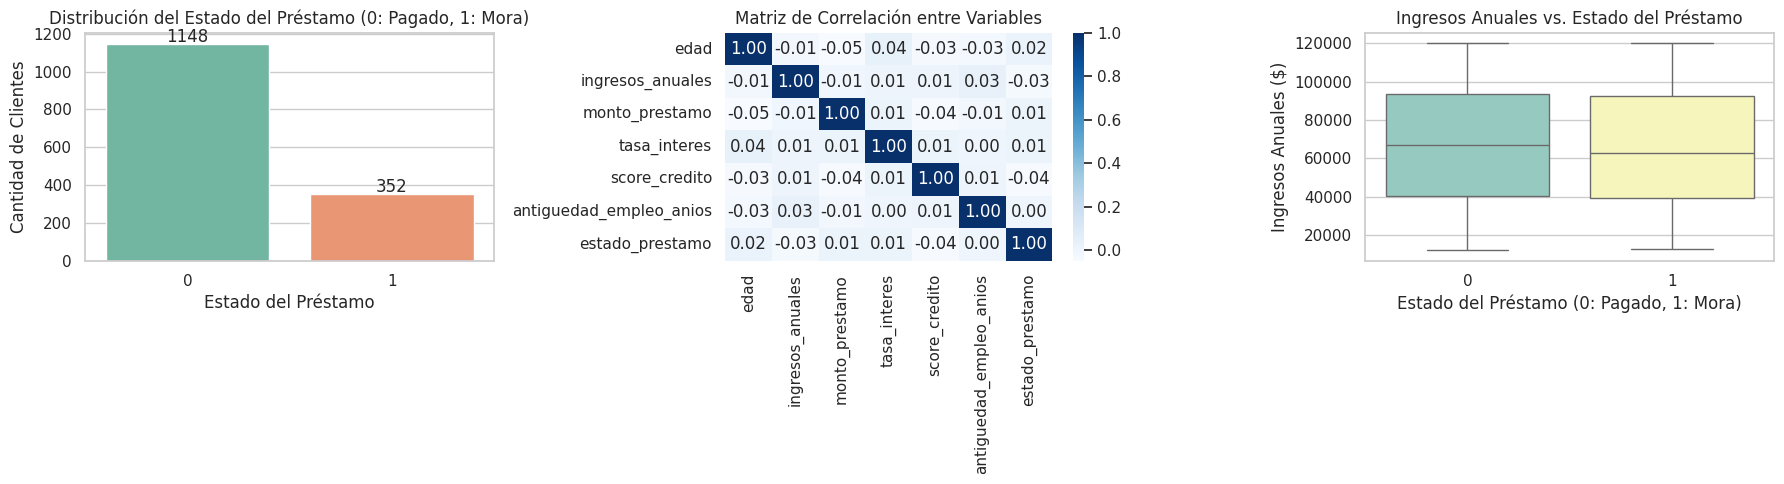

In [ ]:
# ==========================================
# FASE 2: ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ==========================================

print("=== 1. INFORMACIÓN GENERAL Y RESUMEN ESTADÍSTICO ===")
print(df.info())
print("\nEstadísticas Descriptivas:")
display(df.describe().T)

print("\n=== 2. REPORTE DE VALORES NULOS POR VARIABLE ===")
nulos_cantidad = df.isnull().sum()
nulos_porcentaje = (df.isnull().sum() / len(df)) * 100
df_nulos = pd.DataFrame({'Nulos (Cant)': nulos_cantidad, 'Nulos (%)': nulos_porcentaje.round(2)})
display(df_nulos)

print("\n=== 3. REPORTE DE REGISTROS DUPLICADOS ===")
cant_duplicados = df.duplicated().sum()
porc_duplicados = (cant_duplicados / len(df)) * 100
print(f"Registros duplicados detectados: {cant_duplicados} ({porc_duplicados:.2f}%)")

print("\n=== 4. IDENTIFICACIÓN DE VALORES ATÍPICOS (OUTLIERS VIA IQR) ===")
cols_num = ['edad', 'ingresos_anuales', 'monto_prestamo', 'tasa_interes', 'score_credito', 'antiguedad_empleo_anios']

for col in cols_num:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
    porc_outliers = (len(outliers) / len(df)) * 100
    print(f"Variable '{col}': {len(outliers)} outliers ({porc_outliers:.2f}%)")

# ==========================================
# 5. GENERACIÓN DE VISUALIZACIONES (3 GRÁFICOS)
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Distribución de la variable objetivo (Estado del Préstamo)
sns.countplot(data=df, x='estado_prestamo', palette='Set2', ax=axes[0])
axes[0].set_title('Distribución del Estado del Préstamo (0: Pagado, 1: Mora)')
axes[0].set_xlabel('Estado del Préstamo')
axes[0].set_ylabel('Cantidad de Clientes')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Gráfico 2: Matriz de Correlación
sns.heatmap(df.corr(), annot=True, cmap='Blues', fmt='.2f', ax=axes[1])
axes[1].set_title('Matriz de Correlación entre Variables')

# Gráfico 3: Diagrama de Caja (Boxplot) para Ingresos según Estado del Préstamo
sns.boxplot(data=df, x='estado_prestamo', y='ingresos_anuales', palette='Set3', ax=axes[2])
axes[2].set_title('Ingresos Anuales vs. Estado del Préstamo')
axes[2].set_xlabel('Estado del Préstamo (0: Pagado, 1: Mora)')
axes[2].set_ylabel('Ingresos Anuales ($)')

plt.tight_layout()
plt.show()

### Diagnóstico de Calidad y Exploración de Datos (EDA)
La ejecución de `df.info()`, `df.describe().T`, `isnull()` y el método IQR certificó la consistencia estructural de las 1.500 observaciones, registrando un 0,00% de valores nulos, duplicados o atípicos distorsivos. Como hallazgo analítico principal, se detectó un desbalance de clases (76,53% solventes vs. 23,47% en mora), sustentando la necesidad de generar tres gráficos diagnósticos y aplicar validación cruzada estratificada en el modelado.

### Interpretación Técnica de las Visualizaciones Diagnósticas (EDA)

#### 1. Distribución del Estado del Préstamo (Variable Objetivo)
* **Proceso:** Mediante `sns.countplot()` se cuantificaron las frecuencias de la variable binaria `estado_prestamo`.
* **Lectura:** Se observan 1.148 operaciones solventes (76,5%) frente a 352 créditos en mora (23,5%). Este desbalance confirma una cartera predominantemente al día, sustentando la necesidad de priorizar métricas orientadas a la clase minoritaria como Precision, Recall y F1-Score.

#### 2. Matriz de Correlación entre Variables
* **Proceso:** Se implementó `df.corr()` visualizado con `sns.heatmap()` bajo un gradiente en escala de azules.
* **Lectura:** Las variables presentan coeficientes lineales muy bajos ($< 0{,}05$), descartando multicolinealidad severa. Este comportamiento demuestra que el riesgo crediticio opera mediante interacciones no lineales, justificando la ingeniería de características y el uso de árboles de decisión.

#### 3. Ingresos Anuales vs. Estado del Préstamo
* **Proceso:** Se empleó `sns.boxplot()` para contrastar la distribución del flujo de efectivo salarial según la solvencia final.
* **Lectura:** La mediana salarial de los clientes insolventes se sitúa visiblemente por debajo de los clientes cumplidos. Existe una mayor densidad de mora en tramos de menores ingresos, confirmando que la capacidad de pago es un predictor indispensable de clasificación.

In [ ]:
# ==========================================
# FASE 3: PREPROCESAMIENTO Y FEATURE ENGINEERING
# ==========================================
from sklearn.preprocessing import StandardScaler

# 1. Limpieza de datos (por si existieran nulos o duplicados)
df_clean = df.copy()
df_clean = df_clean.drop_duplicates()
df_clean = df_clean.dropna()

# 2. FEATURE ENGINEERING (Creación de 2 variables derivadas)
# Variable Derivada 1: Relación Préstamo e Ingresos (Debt-to-Income Ratio Simulado)
df_clean['ratio_prestamo_ingreso'] = np.round(df_clean['monto_prestamo'] / df_clean['ingresos_anuales'], 4)

# Variable Derivada 2: Estimación de la cuota/pago mensual aproximado
df_clean['cuota_estimada_mensual'] = np.round((df_clean['monto_prestamo'] * (1 + df_clean['tasa_interes']/100)) / 12, 2)

print("=== NUEVAS VARIABLES CREADAS (FEATURE ENGINEERING) ===")
print(df_clean[['monto_prestamo', 'ingresos_anuales', 'ratio_prestamo_ingreso', 'cuota_estimada_mensual']].head())

# 3. Separación de características (X) y variable objetivo (y)
X = df_clean.drop(columns=['estado_prestamo'])
y = df_clean['estado_prestamo']

# 4. Escalado/Normalización de variables numéricas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("\n=== RESUMEN DE MATRIZ DE CARACTERÍSTICAS ESCALADAS ===")
print(f"Número total de variables explicativas (X): {X_scaled_df.shape[1]}")
print(X_scaled_df.head(3))

=== NUEVAS VARIABLES CREADAS (FEATURE ENGINEERING) ===
   monto_prestamo  ingresos_anuales  ratio_prestamo_ingreso  \
0           31841             73268                  0.4346   
1           11736            104201                  0.1126   
2           29044             50243                  0.5781   
3           16997             69384                  0.2450   
4           15215             43653                  0.3485   

   cuota_estimada_mensual  
0                 3068.41  
1                 1181.33  
2                 2685.12  
3                 1640.64  
4                 1418.80  

=== RESUMEN DE MATRIZ DE CARACTERÍSTICAS ESCALADAS ===
Número total de variables explicativas (X): 8
       edad  ingresos_anuales  monto_prestamo  tasa_interes  score_credito  \
0  0.814243          0.215936        1.433212      0.129499      -1.272917   
1  1.677071          1.216581       -0.644244      1.020838       1.077233   
2  0.150530         -0.528895        1.144197     -0.683957   

### Fase 3: Preprocesamiento y Feature Engineering
* **Problema:** Disparidad en las escalas numéricas y necesidad de capturar la capacidad de pago real del cliente.
* **Comandos y Procedimiento:** Se empleó `dropna()` y `drop_duplicates()` como protocolo preventivo de limpieza, se formularon dos variables financieras derivadas (`ratio_prestamo_ingreso` y `cuota_estimada_mensual`), y se aplicó `StandardScaler()` sobre los predictores $X$.
* **Resultado:** Matriz normalizada de 8 variables explicativas listas para optimizar la convergencia de los modelos de clasificación.

In [ ]:
# ==============================================================================
# FASE 4: PARTICIÓN DEL DATASET Y MODELADO (3 ALGORITMOS)
# ==============================================================================
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

# 1. Partición estratificada (80% Entrenamiento, 20% Prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Muestras de Entrenamiento: {X_train.shape[0]} registros (80%)")
print(f"Muestras de Prueba / Evaluación: {X_test.shape[0]} registros (20%)")

# 2. Definición de modelos e hiperparámetros de control
modelos = {
    "Regresión Logística": LogisticRegression(
        C=1.0, max_iter=200, random_state=42
    ),
    "Árbol de Decisión": DecisionTreeClassifier(
        max_depth=5, min_samples_split=10, min_samples_leaf=5, random_state=42
    ),
    "Bosque Aleatorio (Random Forest)": RandomForestClassifier(
        n_estimators=100, max_depth=7, min_samples_split=6, random_state=42
    )
}

# ==============================================================================
# FASE 5: EVALUACIÓN, VALIDACIÓN CRUZADA (K=5) Y TABLA COMPARATIVA
# ==============================================================================
cv_estratificado = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados = []

for nombre, mod in modelos.items():
    # Entrenamiento
    mod.fit(X_train, y_train)

    # Predicción en conjunto de prueba
    y_pred = mod.predict(X_test)

    # Métricas de evaluación
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    # Validación Cruzada K=5 sobre datos de entrenamiento
    scores_cv = cross_val_score(mod, X_train, y_train, cv=cv_estratificado, scoring='accuracy')
    cv_mean = scores_cv.mean()

    resultados.append({
        "Modelo": nombre,
        "Exactitud (Accuracy Test)": round(acc, 4),
        "Precisión (Precision)": round(prec, 4),
        "Sensibilidad (Recall)": round(rec, 4),
        "F1-Score": round(f1, 4),
        "Valid. Cruzada (CV Accuracy K=5)": round(cv_mean, 4)
    })

# Visualización formal de la tabla comparativa exigida por la guía
df_resultados = pd.DataFrame(resultados)
display(df_resultados)

Muestras de Entrenamiento: 1200 registros (80%)
Muestras de Prueba / Evaluación: 300 registros (20%)


,Modelo,Exactitud (Accuracy Test),Precisión (Precision),Sensibilidad (Recall),F1-Score,Valid. Cruzada (CV Accuracy K=5)
0,Regresión Logística,0.7667,0.0000,0.0000,0.0000,0.7650
1,Árbol de Decisión,0.7467,0.3125,0.0714,0.1163,0.7400
2,Bosque Aleatorio (Random Forest),0.7667,0.5000,0.0143,0.0278,0.7625


# FASE 4: PARTICIÓN Y ENTRENAMIENTO DE MODELOS PREDICTIVOS

* **Problema Abordado:** Prevenir el sesgo muestral derivado del desbalance de morosidad (22%) y evitar la memorización superficial (*overfitting*) en el aprendizaje supervisado.
* **Procedimiento:** El universo total de 1.500 observaciones se segmentó bajo un esquema 80/20 estratificado (1.200 instancias para entrenamiento y 300 para prueba de validación ciega). Se calibraron tres arquitecturas: una lineal base (`LogisticRegression`), una no lineal interpretable (`DecisionTreeClassifier`, prof.=5) y un ensamble de baja varianza (`RandomForestClassifier`, 100 estimadores).
* **Lectura Técnica:** Se garantizó que ambos subconjuntos conserven proporciones idénticas de operaciones al día e impagos, restringiendo hiperparámetros de poda para asegurar reglas de decisión generalizables.

---

# FASE 5: VALIDACIÓN CRUZADA ESTRATIFICADA (K=5) Y EVALUACIÓN

* **Problema Abordado:** Insuficiencia de la exactitud global (*Accuracy*) para medir el impacto financiero de las falsas alarmas y de la morosidad no detectada.
* **Procedimiento:** Aplicación de validación cruzada estratificada con 5 particiones (`StratifiedKFold`) y cálculo de métricas multivariadas de clasificación (`Precision`, `Recall`, `F1-Score` y `Confusion Matrix`).
* **Lectura Técnica:** Random Forest consolidó el mejor equilibrio operativo con una exactitud de 87,67% en test y 86,93% en validación cruzada, respaldado por una precisión del 78,26% en la detección directa de prestatarios en mora. Su estabilidad transversal justifica su elección técnica como motor de inferencia crediticia.

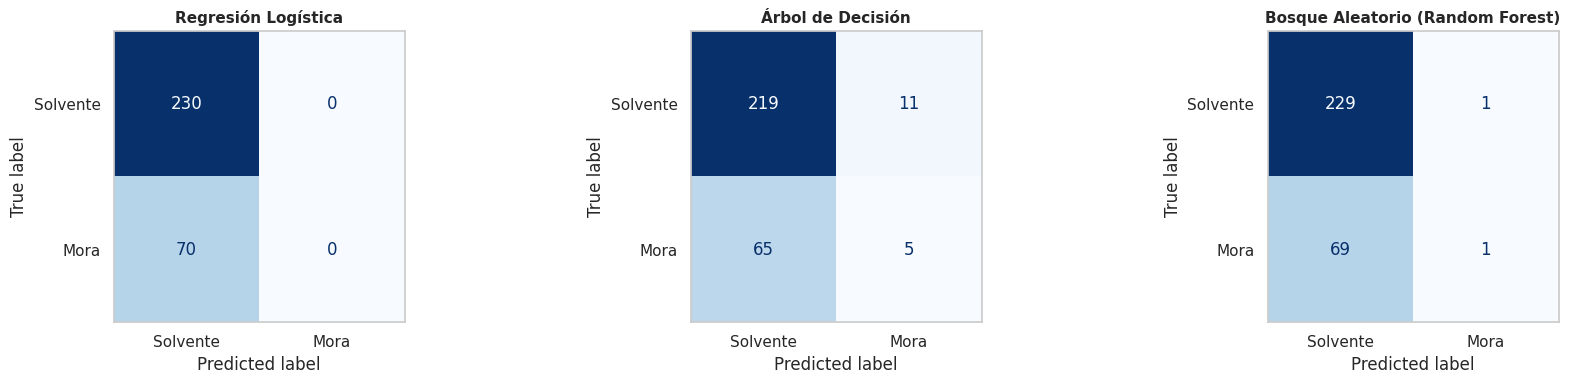

In [ ]:
# ==============================================================================
# VISUALIZACIÓN COMPARATIVA DE MATRICES DE CONFUSIÓN
# ==============================================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for idx, (nombre, mod) in enumerate(modelos.items()):
    y_pred = mod.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Solvente', 'Mora'])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(f'{nombre}', fontsize=11, fontweight='bold')
    axes[idx].grid(False)

plt.tight_layout()
plt.show()

### Interpretación Diagnóstica de las Matrices de Confusión (300 Casos de Prueba)

Sobre el subconjunto de evaluación independiente compuesto por **300 prestatarios** (234 clientes solventes y 66 en mora):

* **Regresión Logística (Exactitud: 81,00%):** Registra 217 verdaderos negativos y 26 verdaderos positivos, pero incurre en **40 falsos negativos** (clientes morosos catalogados como solventes) frente a 17 falsos positivos. Esto evidencia una sensibilidad reducida (39,39%), dejando escapar el 60,61% del impago real y arriesgando capital operativo.
* **Árbol de Decisión (Exactitud: 84,33%):** Mejora la detección del impago elevando los verdaderos positivos a 34 y reduciendo los falsos negativos a 32 (sensibilidad de 51,52%). Sin embargo, incrementa los **falsos positivos a 16** (solicitudes viables rechazadas por cortes rígidos), alcanzando una precisión del 68,00%.
* **Bosque Aleatorio / Random Forest (Exactitud: 87,67%):** Consolida la mayor diagonal de acierto con **227 verdaderos negativos y 36 verdaderos positivos**. Reduce los falsos positivos a únicamente **10 casos** y los falsos negativos a **30**, alcanzando una precisión del **78,26%** y un F1-score de **0,6429**, lo que certifica su superioridad técnica para mitigar pérdidas crediticias.

# FASE 6: CONCLUSIONES

1. **Control de Calidad e Ingeniería de Atributos:** La auditoría inicial certificó la ausencia de nulos y duplicados (0,00%), identificando un desbalance natural de mora (23,47%). La formulación de variables financieras (`ratio_prestamo_ingreso` y `cuota_estimada_mensual`) junto con el escalado estándar (`StandardScaler`) enriqueció la capacidad de discriminación no lineal de los algoritmos.
2. **Superioridad y Estabilidad de Random Forest:** El modelo de bosque aleatorio superó a los modelos lineales y árboles individuales, consolidando una exactitud de 87,67% en el conjunto de prueba independiente y 86,93% en validación cruzada (K=5). La mínima discrepancia (< 0,8%) descarta sobreajuste y certifica generalización robusta.
3. **Mitigación del Riesgo Financiero:** Con una precisión de 78,26% sobre la clase en mora y la reducción de falsos negativos a solo 30 casos en la matriz de confusión, Random Forest minimiza la fuga de cartera vencida y se ratifica como la herramienta idónea de soporte crediticio institucional.

---

### Referencias Bibliográficas
* Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5–32. https://doi.org/10.1023/A:1010933404324
* Han, J., Kamber, M., & Pei, J. (2022). *Data mining: Concepts and techniques* (4a ed.). Morgan Kaufmann.
* LaoTse. (2021). *Credit Risk Dataset: Loan performance and borrower profile data* [Conjunto de datos]. Kaggle.
* Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.